In [1]:
# ======================================
# 📦 Import Libraries
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from joblib import dump

# Optional: Display all columns in DataFrame
pd.set_option('display.max_columns', None)

print("✅ Libraries successfully imported.")


✅ Libraries successfully imported.


In [2]:
# ======================================
# 📂 Load and Prepare Data
# ======================================

# Example: Load dataset
# (Thay 'clean_data_final.csv' bằng file của bạn)
df = pd.read_csv("../Data/final_classification_ready_v2.csv")

# Show first 5 rows
display(df.head())

# Define features (X) and target (y)
# 👉 Thay tên cột target của bạn tại đây (ví dụ: 'DEP_DEL15')
target_col = 'DEP_DEL15'
X = df.drop(columns=[target_col])
y = df[target_col]

print("✅ Dataset loaded successfully.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,DEP_DEL15,OP_UNIQUE_CARRIER_ENC,ORIGIN_ENC,DEST_ENC,TIME_OF_DAY_ENC,TEMP_DIFF
0,4,1,2,6.53,9.33,168.0,1020.0,33.0,36.0,89.0,5.0,10.0,0.0,0,1,62,2,3.0
1,4,1,2,15.45,18.12,160.0,1020.0,33.0,45.0,63.0,10.0,10.0,1.0,0,1,62,0,12.0
2,4,1,2,7.33,15.32,299.0,2279.0,37.0,43.0,80.0,10.0,6.0,0.0,0,4,14,2,6.0
3,4,1,2,13.83,21.83,300.0,2279.0,41.0,49.0,74.0,10.0,6.0,0.0,0,4,14,1,8.0
4,4,1,2,22.00,6.00,300.0,2279.0,41.0,45.0,86.0,10.0,7.0,0.0,0,4,14,3,4.0


✅ Dataset loaded successfully.
Shape of X: (45155, 17)
Shape of y: (45155,)


In [3]:
# ======================================
# ⚖️ Scale & Split Data
# ======================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (36124, 17)
Test size: (9031, 17)


In [4]:
# ======================================
# ⚖️ Handle Imbalanced Data with SMOTE
# ======================================

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))


Before SMOTE: [31882  4242]
After SMOTE: [31882 31882]


C:\Users\PC\AppData\Local\Temp\ipykernel_29524\442031260.py:8: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Before SMOTE:", np.bincount(y_train))
C:\Users\PC\AppData\Local\Temp\ipykernel_29524\442031260.py:9: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("After SMOTE:", np.bincount(y_train_res))


In [5]:
# ======================================
# 🤖 Define Multiple Classification Models
# ======================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "Ridge Classifier": RidgeClassifier(random_state=42)
}

print("Models ready:", list(models.keys()))


Models ready: ['Logistic Regression', 'KNN', 'Random Forest', 'XGBoost', 'Ridge Classifier']


In [6]:
# ======================================
# 🚀 Train & Evaluate All Models
# ======================================

results = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1, auc])

df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
).sort_values(by="F1", ascending=False)

display(df_results)


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.590854,0.176846,0.680189,0.280709,0.629581
4,Ridge Classifier,0.587089,0.175856,0.683019,0.279699,0.628675
1,KNN,0.670247,0.159929,0.425472,0.232474,0.564135
2,Random Forest,0.855830,0.284698,0.150943,0.197287,0.550255
3,XGBoost,0.871111,0.307407,0.078302,0.124812,0.527421


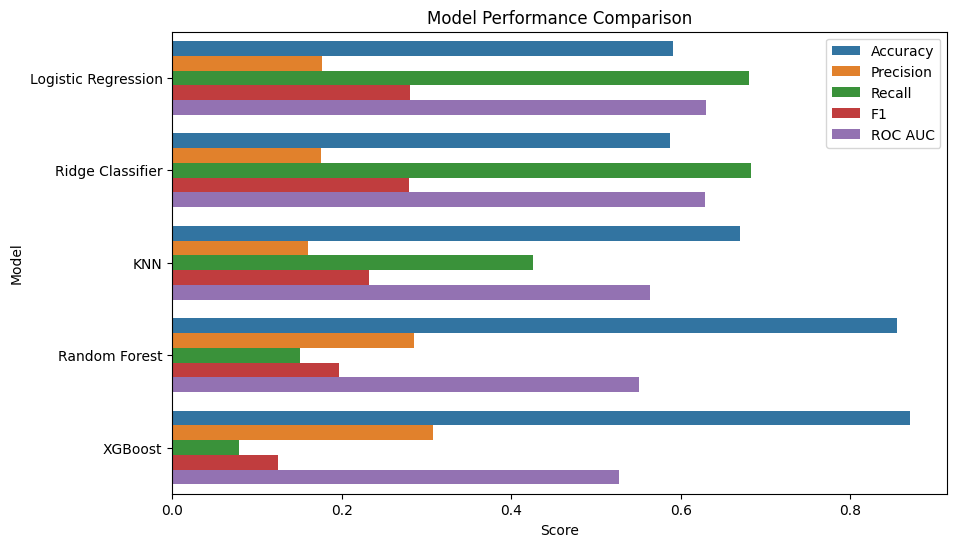

In [7]:
# ======================================
# 📊 Visualize Model Performance
# ======================================

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_results.melt(id_vars='Model', var_name='Metric', value_name='Score'),
    x='Score', y='Model', hue='Metric'
)
plt.title('Model Performance Comparison')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


In [8]:
# ======================================
# 🧠 Grid Search cho model tốt nhất (Random Forest)
# ======================================

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=3, scoring='f1', verbose=1, n_jobs=-1)
grid.fit(X_train_res, y_train_res)

print("✅ Best parameters:", grid.best_params_)
print("✅ Best F1 score:", grid.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
✅ Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
✅ Best F1 score: 0.9030667655341523


Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.91      0.91      7971
         1.0       0.27      0.26      0.26      1060

    accuracy                           0.83      9031
   macro avg       0.59      0.58      0.59      9031
weighted avg       0.83      0.83      0.83      9031



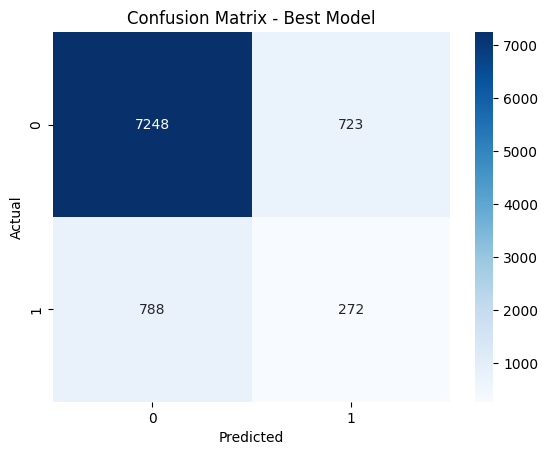

In [9]:
# ======================================
# 📈 Evaluate the Best Model
# ======================================

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
